# Финальный проект:
# **ReviewAI: интеллектуальный анализ клиентских отзывов**

**Цель проекта:** разработать систему для автоматического определения тональности русскоязычных отзывов о товарах.

**Основная задача:** по тексту отзыва определить его тональность:

- positive — положительная;
- neutral — нейтральная;
- negative — отрицательная.

В проекте используется датасет русскоязычных отзывов о товарах Wildberries.

Исходные данные содержат текст отзыва, рейтинг товара и дополнительную информацию об отзыве. На основе рейтинга формируется целевая переменная *"sentiment"* с тремя классами тональности.

В рамках проекта будут проведены:
- исследовательский анализ данных (EDA);
- подготовка текстовых данных;
- построение моделей классификации;
- сравнение моделей по метрикам качества;
- анализ ошибок;
- создание AI-агента для анализа отзывов и формирования рекомендаций для бизнеса;
- создание веб-интерфейса для демонстрации итоговой модели.

In [5]:
import pandas as pd
df = pd.read_csv(
    '/content/filtered.csv'
)

df.head()

,review_id,product_id,category,category_label,rating,text,pros,cons,date
0,1,1,electronics,Электроника,5,"Звук не плохой, максимальная громкость высокая...",Отличные наушники за свои деньги,Минусов нет,2026-06-28
1,2,1,electronics,Электроника,5,NaN,"Ничего. Подключалась 3 дня еле подключилась, н...",NaN,2026-06-26
2,3,1,electronics,Электроника,5,Сразу после первого подключения не работал вто...,NaN,NaN,2026-06-26
3,4,1,electronics,Электроника,1,Ничего нового наушники так и лежат не работают...,NaN,NaN,2026-06-23
4,5,2,electronics,Электроника,5,"Пока всё работает. Звук чистый, басы на месте,...",NaN,NaN,2026-07-19


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27248 entries, 0 to 27247
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review_id       27248 non-null  int64 
 1   product_id      27248 non-null  int64 
 2   category        27248 non-null  object
 3   category_label  27248 non-null  object
 4   rating          27248 non-null  int64 
 5   text            19559 non-null  object
 6   pros            13576 non-null  object
 7   cons            8412 non-null   object
 8   date            27248 non-null  object
dtypes: int64(3), object(6)
memory usage: 1.9+ MB


## Исследовательский анализ данных (EDA)

Проведем первичный анализ данных: проверим пропуски, дубликаты, распределение рейтингов и категорий товаров.

In [7]:
df.isnull().sum()

,0
review_id,0
product_id,0
category,0
category_label,0
rating,0
text,7689
pros,13672
cons,18836
date,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[['text', 'pros', 'cons']].isnull().all(axis=1).sum()

np.int64(0)

In [10]:
df['full_text'] = (df['text'].fillna('') + ' ' + df['pros'].fillna('') + ' ' + df['cons'].fillna('')).str.strip()
df[['text', 'pros', 'cons', 'full_text']].head()

,text,pros,cons,full_text
0,"Звук не плохой, максимальная громкость высокая...",Отличные наушники за свои деньги,Минусов нет,"Звук не плохой, максимальная громкость высокая..."
1,NaN,"Ничего. Подключалась 3 дня еле подключилась, н...",NaN,"Ничего. Подключалась 3 дня еле подключилась, н..."
2,Сразу после первого подключения не работал вто...,NaN,NaN,Сразу после первого подключения не работал вто...
3,Ничего нового наушники так и лежат не работают...,NaN,NaN,Ничего нового наушники так и лежат не работают...
4,"Пока всё работает. Звук чистый, басы на месте,...",NaN,NaN,"Пока всё работает. Звук чистый, басы на месте,..."


**Вывод:** Полных дубликатов в данных не обнаружено. В текстовых полях присутствует значительное количество пропущенных значений, однако нет отзывов, в которых одновременно отсутствуют text, pros и cons. Поэтому пропуски заменены пустыми строками, а текстовые поля объединены в единый признак full_text, который будет использоваться для дальнейшего анализа и обучения моделей.

In [11]:
df['rating'].value_counts().sort_index()

,count
rating,
1,3385
2,1180
3,2280
4,2928
5,17475


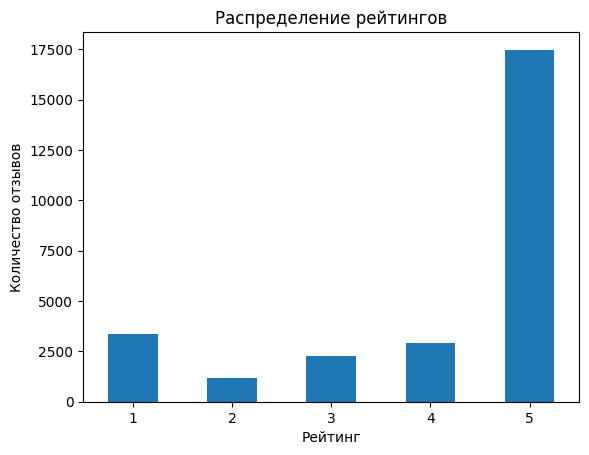

In [12]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.show()

**Вывод:** Распределение рейтингов неравномерное. Большинство отзывов имеют рейтинг 5, при этом остальные оценки встречаются значительно реже. Это указывает на дисбаланс данных, который необходимо учитывать при построении модели классификации тональности.

In [13]:
df['category_label'].value_counts()

,count
category_label,
Косметика и уход,6008
Электроника,4733
Одежда и обувь,4534
Спорт и отдых,3312
Детские товары,3110
Товары для дома,2852
Продукты питания,2699


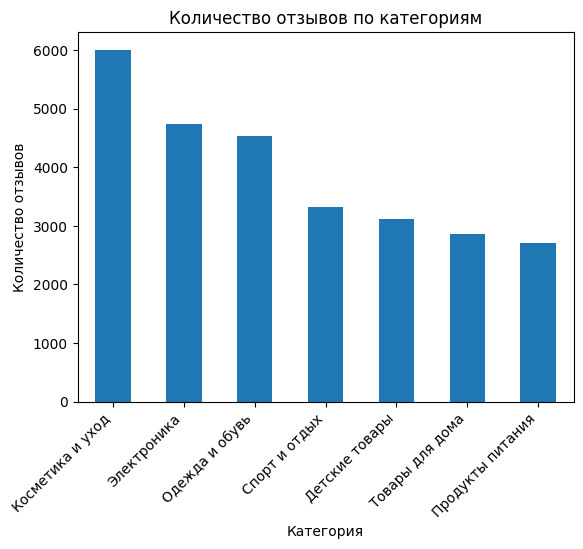

In [14]:
df['category_label'].value_counts().plot(kind='bar')
plt.title('Количество отзывов по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=45, ha='right')
plt.show()

**Вывод:** Наибольшее количество отзывов относится к категории "Косметика и уход". Меньше всего отзывов представлено в категории "Продукты питания". При этом все категории представлены достаточным количеством наблюдений для дальнейшего анализа.

In [15]:
rating_by_category = df.groupby('category_label')['rating'].mean().sort_values().round(2)

rating_by_category

,rating
category_label,
Электроника,3.87
Продукты питания,3.98
Детские товары,4.07
Товары для дома,4.07
Спорт и отдых,4.13
Косметика и уход,4.23
Одежда и обувь,4.24


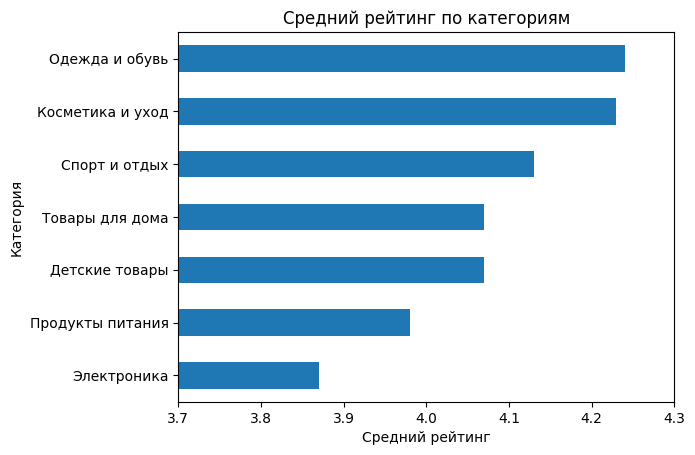

In [16]:
rating_by_category.plot(kind='barh')
plt.title('Средний рейтинг по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.xlim(3.7, 4.3)
plt.show()

**Вывод:** Средний рейтинг во всех категориях достаточно высокий и находится примерно в диапазоне от 3,9 до 4,2. Наиболее высокий средний рейтинг наблюдается в категории "Одежда и обувь", а наиболее низкий - в категории "Электроника". При этом различия между категориями относительно небольшие.

In [55]:
df['text_length'] = df['full_text'].str.split().str.len()

df['text_length'].describe().round(2)

,text_length
count,27248.00
mean,34.84
std,19.06
min,20.00
25%,23.00
50%,29.00
75%,39.00
max,273.00


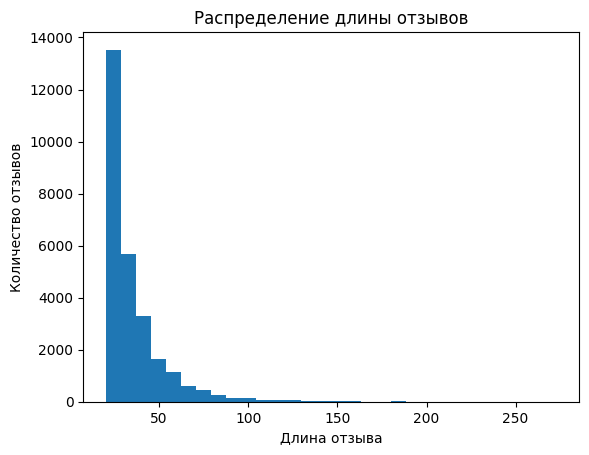

In [18]:
df['text_length'].plot(kind='hist', bins=30)
plt.title('Распределение длины отзывов')
plt.xlabel('Длина отзыва')
plt.ylabel('Количество отзывов')
plt.show()

**Вывод:** Большинство отзывов имеют небольшую длину. Средняя длина составляет около 35 слов, а медианная — 29 слов. Распределение имеет длинный правый хвост: встречаются отдельные отзывы длиной более 100 слов, максимальная длина составляет 273 слова.

In [19]:
def get_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
positive,20403
negative,4565
neutral,2280


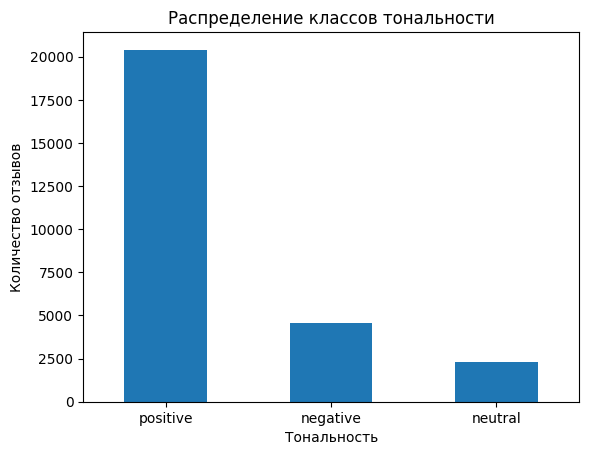

In [20]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Распределение классов тональности')
plt.xlabel('Тональность')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.show()

**Вывод:** В данных наблюдается выраженный дисбаланс классов: положительных отзывов значительно больше, чем отрицательных и нейтральных. Поэтому при оценке моделей важно учитывать не только Accuracy, но и F1-score, особенно Macro F1.

Для обучения модели используется объединенный текст отзыва full_text. Целевая переменная sentiment сформирована на основе рейтинга: оценки 1-2 - negative, 3 - neutral, 4-5 - positive.

### Сохранение обработанных данных

Сохраним подготовленный датасет с объединенным текстом отзывов и целевой переменной sentiment.

In [21]:
processed_df = df[['full_text', 'sentiment']].copy()
processed_df.to_csv('processed_reviews.csv', index=False)

print('Размер обработанного датасета:', processed_df.shape)
processed_df.head()

Размер обработанного датасета: (27248, 2)


,full_text,sentiment
0,"Звук не плохой, максимальная громкость высокая...",positive
1,"Ничего. Подключалась 3 дня еле подключилась, н...",positive
2,Сразу после первого подключения не работал вто...,positive
3,Ничего нового наушники так и лежат не работают...,negative
4,"Пока всё работает. Звук чистый, басы на месте,...",positive


In [22]:
from google.colab import files

files.download('processed_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from sklearn.model_selection import train_test_split

x = df['full_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Обучающая выборка:', len(X_train))
print('Тестовая выборка:', len(X_test))

Обучающая выборка: 21798
Тестовая выборка: 5450


## Базовая модель: TF-IDF + Logistic Regression

Преобразуем тексты отзывов в числовые признаки с помощью TF-IDF и обучим логистическую регрессию для классификации тональности.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(21798, 10000)
(5450, 10000)


In [25]:
model = LogisticRegression(max_iter=1000, class_weight = 'balanced')
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print('Модель обучена')

Модель обучена


## Оценка качества базовой модели

Оценим качество классификации тональности на тестовой выборке с помощью Accuracy, Precision, Recall и F1-score.

In [26]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy,3))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.804

              precision    recall  f1-score   support

    negative       0.66      0.72      0.69       913
     neutral       0.27      0.45      0.33       456
    positive       0.95      0.86      0.91      4081

    accuracy                           0.80      5450
   macro avg       0.63      0.68      0.64      5450
weighted avg       0.85      0.80      0.82      5450



**Вывод:** Базовая модель Logistic Regression показала Accuracy 0.80 и Macro F1 0.64. Лучше всего модель распознаёт положительные отзывы (F1 = 0.91), а наиболее сложным оказался нейтральный класс (F1 = 0.33). Это может быть связано с дисбалансом классов и неоднозначностью формулировок нейтральных отзывов.

## Матрица ошибок

Матрица ошибок позволяет увидеть, какие классы тональности модель чаще всего путает между собой.

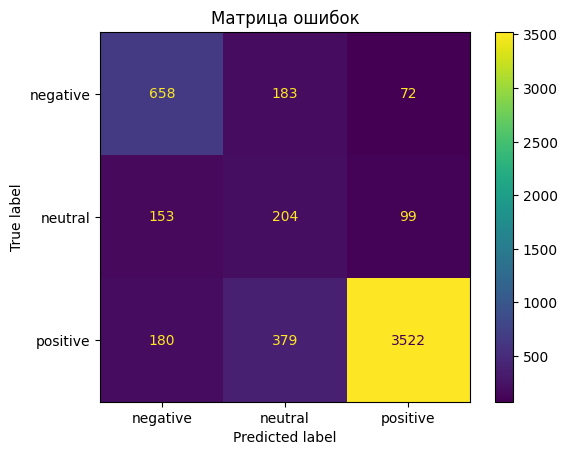

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
plt.title('Матрица ошибок')
plt.show()

**Вывод:** Матрица ошибок показывает, что модель лучше всего распознаёт положительные отзывы. Наибольшие сложности возникают с нейтральным классом: нейтральные отзывы часто классифицируются как отрицательные. Также часть положительных отзывов модель относит к нейтральным.

## Модель LinearSVC

В качестве второй модели модели используем LinearSVC и сравним её качество с базовой Logistic Regression на одинаковых TF-IDF признаках.

In [28]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print('Модель LinearSVC обучена')

Модель LinearSVC обучена


## Оценка качества LinearSVC

Оценим качество второй модели на тестовой выборке и сравним результаты с базовой Logistic Regression.

In [29]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print('Accuracy LinearSVC:', round(accuracy_svm,3))
print()
print(classification_report(y_test, y_pred_svm))

Accuracy LinearSVC: 0.833

              precision    recall  f1-score   support

    negative       0.69      0.69      0.69       913
     neutral       0.31      0.30      0.31       456
    positive       0.92      0.92      0.92      4081

    accuracy                           0.83      5450
   macro avg       0.64      0.64      0.64      5450
weighted avg       0.83      0.83      0.83      5450



**Вывод:** LinearSVC показала более высокую Accuracy (0.833) по сравнению с Logistic Regression (0.804). При этом Macro F1 остался на уровне 0.64, а качество распознавания нейтрального класса остаётся низким (F1 = 0.31). Таким образом, LinearSVC повысила общую точность классификации, но не решила проблему распознавания нейтральных отзывов.

## Сравнение моделей

Сравним Logistic Regression и LinearSVC по основным метрикам. Поскольку классы несбалансированы, помимо Accuracy учитываем Macro F1, который одинаково учитывает качество каждого класса.

In [30]:
from sklearn.metrics import f1_score
import pandas as pd

results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'LinearSVC'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_svm)],
    'Macro F1': [f1_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred_svm, average='macro')],
    'Weighted F1': [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_svm, average='weighted')]
})

results.round(3)


,Модель,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.804,0.644,0.822
1,LinearSVC,0.833,0.641,0.832


## Анализ ошибок модели LinearSVC

Рассмотрим примеры отзывов, на которых модель LinearSVC ошибается, чтобы понять основные причины неправильной классификации.

In [31]:
errors = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'predicted': y_pred_svm})

errors = errors[errors['true'] != errors['predicted']]
print('Количество ошибок:', len(errors))

errors.head(10)

Количество ошибок: 910


,text,true,predicted
23246,"Это не духи, и не туалетная вода, а ПАРФЮМИРОВ...",positive,negative
4169,"В швах рукавов не равномерно синтепон , а знач...",positive,neutral
7596,"Пользуюсь уже несколько месяцев,сейчас пошла у...",negative,positive
24112,"Ткань, лёгкая, приятная, тонкая Размер, на реб...",neutral,negative
13453,"Пришла в очень плохом виде, но думаю это из за...",positive,neutral
18927,Купила эти сапоги перед походом. Стопа проблем...,positive,neutral
549,По качеству звука вполне приемлемый вариант за...,negative,neutral
13131,"Это просто имба , для школы и для поездок , в ...",positive,negative
22988,"Не знаю, на мой взгляд заявленного эффекта нет...",positive,neutral
10839,"На фотографии изделие состоит из 2-х боксов, с...",neutral,negative


In [32]:
pd.crosstab(errors['true'], errors['predicted'])

predicted,negative,neutral,positive
true,,,
negative,0,131,149
neutral,141,0,177
positive,138,174,0


**Вывод:** Анализ ошибок показывает, что LinearSVC чаще всего путает нейтральные отзывы с положительными (177 случаев) и положительные с нейтральными (174 случая). Это может быть связано с тем, что граница между нейтральной и положительной тональностью в текстах отзывов может быть неявной.

## Проверка модели на новых отзывах

Проверим работу модели LinearSVC на новых текстах отзывов. Модель получает текст отзыва и определяет его тональность: positive, neutral или negative.

In [33]:
def predict_sentiment(text):
  text_tfidf = tfidf.transform([text])
  prediction = svm_model.predict(text_tfidf)[0]
  return prediction

reviews = ['Отличный товар, всё работает, покупкой очень доволен', 'Товар ужасного качества, сломался через два дня', 'Обычный товар, ничего особенного']

for review in reviews:
  print('Отзыв:', review)
  print('Тональность:', predict_sentiment(review))
  print()

Отзыв: Отличный товар, всё работает, покупкой очень доволен
Тональность: positive

Отзыв: Товар ужасного качества, сломался через два дня
Тональность: negative

Отзыв: Обычный товар, ничего особенного
Тональность: negative



**Вывод:** На простых положительных и отрицательных примерах LinearSVC правильно определяет тональность. Нейтральный отзыв модель ошибочно отнесла к отрицательному классу, что подтверждает выявленные ранее сложности с распознаванием нейтральных отзывов.

## Transformer-модель

Для дополнительного сравнения используем готовую предобученную модель RuBert для анализа тональности русскоязычных текстов.

In [34]:
!pip install transformers -q

In [35]:
from transformers import pipeline

sentiment_model = pipeline('sentiment-analysis', model='blanchefort/rubert-base-cased-sentiment')

config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  711MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [36]:
test_reviews = ['Отличный товар, всё работает, покупкой очень доволен', 'Товар ужасного качества, сломался через два дня', 'Обычный товар, ничего особенного']

for review in test_reviews:
  result = sentiment_model(review)[0]

  print('Отзыв:', review)
  print('Тональность:', result['label'])
  print('Вероятность:',round(result['score'], 3))
  print()

Отзыв: Отличный товар, всё работает, покупкой очень доволен
Тональность: POSITIVE
Вероятность: 0.981

Отзыв: Товар ужасного качества, сломался через два дня
Тональность: NEGATIVE
Вероятность: 0.752

Отзыв: Обычный товар, ничего особенного
Тональность: NEUTRAL
Вероятность: 0.804



**Промежуточный вывод:** На простых тестовых примерах предобученная Transformer-модель корректно определила все три класса тональности, включая нейтральный отзыв, который LinearSVC отнесла к негативному классу. Однако для объективного сравнения моделей необходимо оценить Transformer на тестовой выборке и рассчитать метрики качества.

## Оценка Transformer-модели

Оценим качество готовой русскоязычной Transformer-модели на части тестовой выборки и сравним её результаты с классическими ML-моделями.

In [37]:
_, X_sample, _, y_sample = train_test_split(X_test, y_test, test_size=500, random_state=42, stratify=y_test)

print(y_sample.value_counts())

sentiment
positive    374
negative     84
neutral      42
Name: count, dtype: int64


In [38]:
transformer_pred = []

for text in X_sample:
  result = sentiment_model(text)[0]
  transformer_pred.append(result['label'].lower())

print('Готово!')
print('Количество предсказаний:', len(transformer_pred))

Готово!
Количество предсказаний: 500


In [39]:
from sklearn.metrics import accuracy_score,f1_score, classification_report

print('Accuracy:', round(accuracy_score(y_sample, transformer_pred),3))
print('Macro F1:', round(f1_score(y_sample, transformer_pred, average='macro'),3))
print('Weighted F1:', round(f1_score(y_sample, transformer_pred, average='weighted'),3))
print()

Accuracy: 0.736
Macro F1: 0.552
Weighted F1: 0.761



In [40]:
X_sample_tfidf = tfidf.transform(X_sample)

lr_sample_pred = model.predict(X_sample_tfidf)
svm_sample_pred = svm_model.predict(X_sample_tfidf)

comparison = pd.DataFrame({
    'Модель': ['Logistic Regression','LinearSVC','Transformer'],
    'Accuracy': [accuracy_score(y_sample, lr_sample_pred), accuracy_score(y_sample, svm_sample_pred), accuracy_score(y_sample, transformer_pred)],
    'Macro F1': [f1_score(y_sample, lr_sample_pred, average='macro'), f1_score(y_sample, svm_sample_pred, average='macro'), f1_score(y_sample, transformer_pred, average='macro')],
    'Weighted F1': [f1_score(y_sample, lr_sample_pred, average='weighted'), f1_score(y_sample, svm_sample_pred, average='weighted'), f1_score(y_sample, transformer_pred, average='weighted')]
})

comparison.round(3)

,Модель,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.796,0.617,0.811
1,LinearSVC,0.808,0.587,0.805
2,Transformer,0.736,0.552,0.761


## Сравнение моделей

Сравним качество трёх моделей по метрикам Accuracy, Macro F1 и Weighted F1.
Так как классы тональности несбалансированы, особое внимание уделим Macro F1.

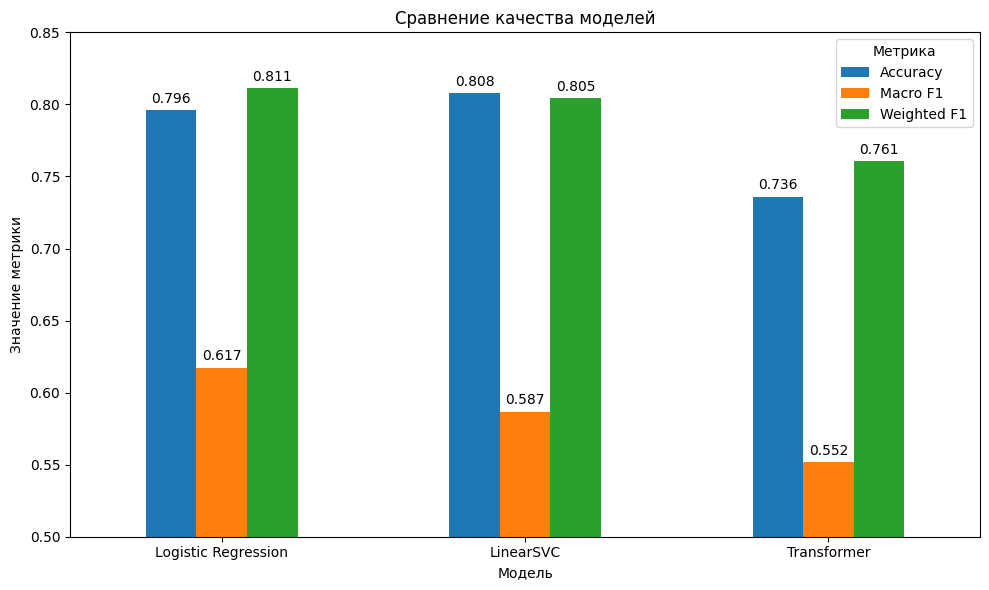

In [41]:
comparison_plot = comparison.set_index('Модель')
ax = comparison_plot.plot(kind='bar', figsize = (10, 6))
plt.title('Сравнение качества моделей')
plt.ylabel('Значение метрики')
plt.xlabel('Модель')
plt.ylim(0.5, 0.85)
plt.xticks(rotation=0)
plt.legend(title='Метрика')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

### Вывод по сравнению моделей

По результатам сравнения на одинаковой тестовой выборке модели показали следующие результаты:

- LinearSVC показала наибольшую Accuracy — 0.808.
- Logistic Regression показала лучший Macro F1 — 0.617 и Weighted F1 — 0.811.
- Transformer-модель показала более низкие результаты: Accuracy — 0.736, Macro F1 — 0.552.

Поскольку классы в датасете распределены неравномерно, одной метрики Accuracy недостаточно для оценки качества модели. В данном случае особенно важна Macro F1, которая учитывает качество классификации каждого класса независимо от его размера.

По совокупности результатов Logistic Regression выбрана в качестве итоговой модели, так как она показывает наиболее сбалансированное качество классификации.

## Анализ ошибок Transformer-модели

Рассмотрим примеры отзывов, на которых Transformer-модель допустила ошибки. Это позволит понять, какие типы текстов вызывают наибольшие сложности при определении тональности.

In [42]:
transformer_errors = pd.DataFrame({
    'text': X_sample,
    'true': y_sample,
    'predicted': transformer_pred})

transformer_errors = transformer_errors[transformer_errors['true'] != transformer_errors['predicted']]

print('Количество ошибок Transformer:', len(transformer_errors))

transformer_errors.head(10)

Количество ошибок Transformer: 132


,text,true,predicted
21513,"Проступила ржавчина как бы, не возвращала , эт...",negative,neutral
3857,"Явно не для минусовой погоды, около нуля я в н...",neutral,positive
10781,"Сложила все мелочи убрала в багажник, и что уд...",positive,negative
12702,Очень расстроилась за не соответствие цвета.И ...,positive,neutral
10762,"Органайзер для белья вместительный, разложила ...",positive,neutral
6668,Ни какого приятного аромата сакуры и близко не...,negative,positive
14969,"Продавец крупный, отвечает на все вопросы. Зак...",positive,negative
22681,"Благодарю создателя этой модели , в морозы -35...",positive,negative
11333,"У меня, часть ступни не работает, перерезаны с...",positive,negative
20469,"Коробка мятая,обернута прозрачной пленкой в 1с...",neutral,negative


In [43]:
pd.crosstab(transformer_errors['true'], transformer_errors['predicted'])

predicted,negative,neutral,positive
true,,,
negative,0,14,11
neutral,22,0,9
positive,34,42,0


### Вывод по анализу ошибок Transformer

Transformer-модель допустила 132 ошибки на выборке из 500 отзывов.

Наиболее часто модель ошибочно относила положительные отзывы к нейтральным (42 случая) и отрицательным (34 случая). Также заметны ошибки при определении нейтрального класса.

Одной из возможных причин является то, что использовалась готовая предобученная модель, которая не дообучалась непосредственно на рассматриваемом датасете отзывов. Кроме того, классы в данных распределены неравномерно, что усложняет корректное распознавание менее представленных классов.

Таким образом, использование более сложной Transformer-модели само по себе не гарантировало более высокого качества классификации по сравнению с классическими моделями, обученными непосредственно на данном датасете.

## Выбор итоговой модели

В работе были протестированы три подхода к классификации тональности отзывов:

- Logistic Regression с TF-IDF;
- LinearSVC с TF-IDF;
- готовая Transformer-модель.

LinearSVC показала наибольшую Accuracy — 0.808, однако Logistic Regression получила лучшие значения Macro F1 — 0.617 и Weighted F1 — 0.811.

Поэтому в качестве итоговой модели выбрана Logistic Regression с TF-IDF. Она показывает наиболее сбалансированный результат и при этом является достаточно быстрой и простой для дальнейшего использования в приложении.

## Сохранение итоговой модели

Сохраним обученную модель Logistic Regression и TF-IDF в отдельные файлы. Это позволит использовать модель для классификации новых отзывов без повторного обучения.

In [44]:
import joblib

joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print('Модель и TF-IDF успешно сохранены')

Модель и TF-IDF успешно сохранены


## Проверка сохраненной модели

Загрузим сохраненную модель и TF-IDF-векторизатор из файлов и проверим их работу на новом отзыве.

In [45]:
loaded_model = joblib.load('sentiment_model.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')

test_text = 'Товар обычный, соответствует описанию'

test_text_tfidf = loaded_tfidf.transform([test_text])
prediction = loaded_model.predict(test_text_tfidf)[0]

print('Отзыв:', test_text)
print('Тональность:', prediction)

Отзыв: Товар обычный, соответствует описанию
Тональность: positive


## AI-агент для анализа отзывов

In [46]:
from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')

if not api_key:
  raise ValueError('Ключ OPENAI_API_KEY не найден в секретах Colab')
print('Ключ API успешно подключен')

Ключ API успешно подключен


In [47]:
!pip install -q -U langchain-openai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 3.0 MB/s eta 0:00:00


In [48]:
import os

os.environ['OPENAI_API_KEY'] = api_key

print('Ключ передан в переменную окружения')

Ключ передан в переменную окружения


In [49]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name='gpt-4.1-mini', temperature=0)

print('LLM успешно подключена')

LLM успешно подключена


In [50]:
from langchain_core.tools import tool

@tool
def predict_sentiment_tool(text: str) -> str:
  """Определяет тональность отзыва: positive, neutral или negative."""
  text_tfidf = loaded_tfidf.transform([text])
  prediction = loaded_model.predict(text_tfidf)[0]
  return prediction

In [51]:
from langchain.agents import create_agent

agent = create_agent(model=llm,
                     tools=[predict_sentiment_tool],
                     system_prompt=("Ты аналитик отзывов для бизнеса. "
                                    "Для определения тональности отзыва обязательно используй "
                                    "инструмент predict_sentiment_tool. "
                                    "После определения тональности кратко объясни результат"))
print("Агент успешно создан")

Агент успешно создан


In [52]:
response = agent.invoke({'messages': [{"role": "user", "content": "Определи тональность отзыва: Товар ужасного качества, больше не буду покупать"}]})

print(response['messages'][-1].content)

Тональность отзыва отрицательная. Клиент выражает недовольство качеством товара и заявляет, что не намерен делать повторные покупки.


### Интерактивная проверка агента

Пользователь может ввести произвольный отзыв. Агент использует обученную ML-модель для определения тональности и формирует краткое объяснение результата.

In [53]:
review = input("Введите текст отзыва: ").strip()

if not review:
    print("Ошибка: введите текст отзыва.")
elif len(review) < 5:
    print("Ошибка: текст отзыва слишком короткий.")
else:
    response = agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": f"Определи тональность отзыва: {review}"
            }
        ]
    })

    print(response["messages"][-1].content)

Введите текст отзыва: Товар хороший, упаковка достойная
Тональность отзыва положительная. Автор доволен качеством товара и упаковкой, что выражено словами "хороший" и "достойная".


### Бизнес-анализ отзывов с помощью AI

На заключительном этапе ML-модель определяет тональность нескольких отзывов, после чего LLM анализирует полученные результаты, выделяет основные жалобы и положительные моменты и формирует рекомендации для бизнеса.

In [54]:
reviews = [
    "Доставка задержалась на три дня",
    "Упаковка была повреждена",
    "Товар отличный, всё понравилось",
    "Курьер приехал очень поздно"
]

analysis_text = ""

for review in reviews:
    sentiment = predict_sentiment_tool.invoke({"text": review})
    analysis_text += f"Отзыв: {review}\nТональность: {sentiment}\n\n"

prompt = f"""
Ты аналитик отзывов для бизнеса.

Ниже приведены отзывы клиентов и тональность,
определённая ML-моделью:

{analysis_text}

Кратко:
1. Выдели основные жалобы клиентов.
2. Укажи положительные моменты.
3. Предложи 2-3 улучшения для бизнеса.
"""

response = llm.invoke(prompt)

print(response.content)

1. Основные жалобы клиентов:
- Задержка доставки (на три дня).
- Повреждённая упаковка.
- Курьер приехал с опозданием.

2. Положительные моменты:
- Товар отличный, клиент доволен качеством.
- Несмотря на проблемы с доставкой и упаковкой, тональность отзывов остаётся положительной, что может указывать на хорошее отношение клиентов к продукту или сервису.

3. Рекомендации по улучшению бизнеса:
- Оптимизировать логистику и работу с курьерами, чтобы минимизировать задержки доставки.
- Улучшить качество упаковки для предотвращения повреждений товара.
- Внедрить систему оповещений клиентов о статусе доставки и возможных задержках для повышения прозрачности и доверия.


### Итоговый вывод:

В рамках проекта была разработана система анализа тональности русскоязычных отзывов Wildberries. По результатам проведённых экспериментов в качестве итоговой модели была выбрана Logistic Regression с TF-IDF.  

Дополнительно был реализован AI-агент, который использует обученную ML-модель как инструмент для определения тональности отзывов. На основе полученных результатов агент может объяснять тональность, анализировать группу отзывов, выделять основные жалобы и положительные моменты, а также формировать рекомендации для бизнеса.    

Таким образом, проект объединяет классическую ML-модель для классификации тональности и LLM для интерпретации результатов и бизнес-анализа. Итоговая модель и TF-IDF-векторизатор сохранены в отдельные файлы для дальнейшего использования. Для взаимодействия с моделью также реализовано веб-приложение на FastAPI, позволяющее вводить новые отзывы и получать результат анализа тональности.